# Import libraries

In [34]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from statsmodels.tsa.seasonal import seasonal_decompose
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# from statsmodels.tsa.stattools import adfuller
# from statsmodels.tsa.holtwinters import ExponentialSmoothing
# from statsmodels.tsa.arima.model import ARIMA
# from statsmodels.tsa.statespace.sarimax import SARIMAX
# from sklearn.metrics import mean_squared_error, mean_absolute_error
# from statsmodels.tsa.arima_process import ArmaProcess
# from statsmodels.tsa.ar_model import AutoReg
# from sklearn.metrics import mean_squared_error, mean_absolute_error,root_mean_squared_error

#To ignore the warnings
import warnings
warnings.filterwarnings('ignore')


# Importing dataset

In [2]:
df = pd.read_csv(r"C:\Users\Shivan\OneDrive\Desktop\ITSFA - Time Sereis Analysis and forecasting\ITSFA Project\sales.csv")

In [150]:
df.head()

,Unnamed: 0,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order_Date
0,0,1,CA-2017-152156,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,08/11/2017
1,1,2,CA-2017-152156,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,08/11/2017
2,2,3,CA-2017-138688,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,12/06/2017
3,3,4,US-2016-108966,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,11/10/2016
4,4,5,US-2016-108966,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,11/10/2016


# Data Prep

In [110]:
df.shape

(9800, 19)

In [4]:
df.isnull().sum()

Unnamed: 0        0
Row ID            0
Order ID          0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Order_Date        0
dtype: int64

###### Postal code has 11 null values.

## Delaing with null values

In [112]:
# finding all countries in df
df['Country'].unique()

array(['United States'], dtype=object)

In [115]:
df[df.isnull().any(axis=1)]

,Unnamed: 0,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order_Date
2234,2234,2235,CA-2018-104066,10/12/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03,05/12/2018
5274,5274,5275,CA-2016-162887,09/11/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,07/11/2016
8798,8798,8799,US-2017-150140,10/04/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,06/04/2017
9146,9146,9147,US-2017-165505,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,23/01/2017
9147,9147,9148,US-2017-165505,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04,23/01/2017
9148,9148,9149,US-2017-165505,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,23/01/2017
9386,9386,9387,US-2018-127292,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92,19/01/2018
9387,9387,9388,US-2018-127292,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28,19/01/2018
9388,9388,9389,US-2018-127292,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,19/01/2018
9389,9389,9390,US-2018-127292,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,19/01/2018


In [116]:
df[(df['City'] =='Burlington') & (df['Region'] == 'East')]

,Unnamed: 0,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order_Date
2234,2234,2235,CA-2018-104066,10/12/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03,05/12/2018
5274,5274,5275,CA-2016-162887,09/11/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,07/11/2016
8798,8798,8799,US-2017-150140,10/04/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,06/04/2017
9146,9146,9147,US-2017-165505,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,23/01/2017
9147,9147,9148,US-2017-165505,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04,23/01/2017
9148,9148,9149,US-2017-165505,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,23/01/2017
9386,9386,9387,US-2018-127292,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92,19/01/2018
9387,9387,9388,US-2018-127292,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28,19/01/2018
9388,9388,9389,US-2018-127292,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,19/01/2018
9389,9389,9390,US-2018-127292,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,19/01/2018


###### All the postal code for Burlington city East are null. These values can't be replaced since there aren't any values where  Burlington city East are not null. So drop these null values

In [117]:
df.dropna(inplace=True)

In [118]:
df.isnull().sum()

Unnamed: 0       0
Row ID           0
Order ID         0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Order_Date       0
dtype: int64

In [43]:
df.shape

(9789, 19)

## Drop unnecessary column

In [329]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [95]:
df.shape

(9789, 18)

## Check for duplicates

In [48]:
df[df.duplicated()] 

,Unnamed: 0,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order_Date


###### no duplicated rows found

In [ ]:
df = df.drop(columns=['Year'])

# Monthly decomposition sales for trends, seasonality and residuals

In [8]:
df2 = df.copy()

df2['Order_Date'] = pd.to_datetime(df2['Order_Date'], format='%d/%m/%Y')

# # Set the 'Order_Date' column as the index
df2.set_index('Order_Date', inplace=True)

# # Resample the data to monthly frequency, assuming 'Sales' column exists
df2 = df2['Sales'].resample('M').sum()

# Perform seasonal decomposition
decomposition = seasonal_decompose(df2, model='additive')

C:\Users\Shivan\AppData\Local\Temp\ipykernel_20072\4097262683.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df2 = df2['Sales'].resample('M').sum()


<Axes: title={'center': 'Total Sales'}, xlabel='Order_Date'>

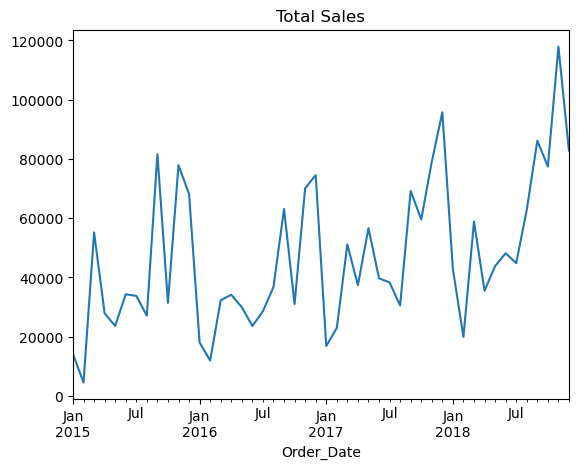

In [209]:
df2.plot(title='Total Sales')

show above is the total sales per month. We can see that there is a increaseing trend Also there is some pattern/seasonality present

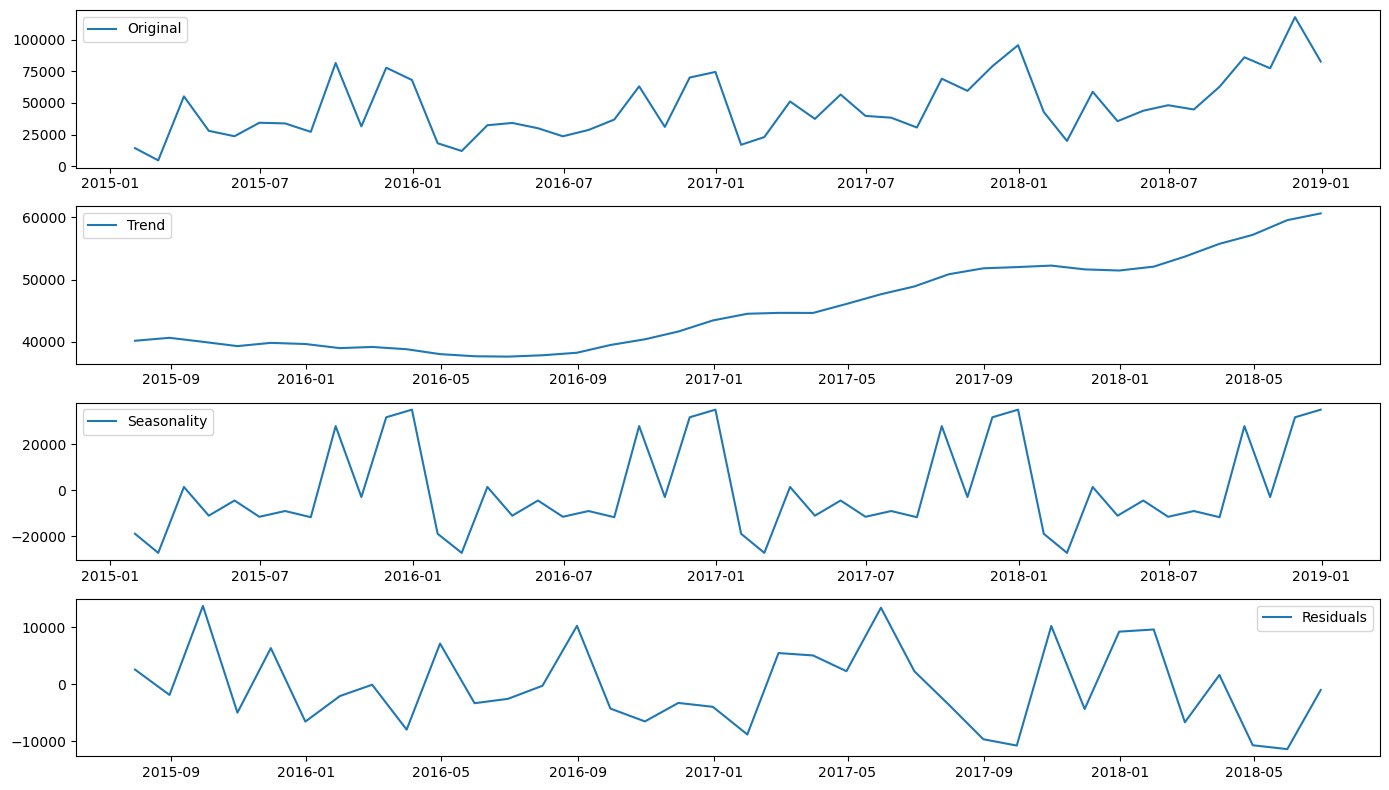

In [191]:
#  Plotting monthly decomposition sales for trends and seasonality
plt.figure(figsize=(14, 8))
plt.subplot(411)
plt.plot(df2, label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()

plt.show()


**Original Series (Top Panel)**

- The raw time series data shows fluctuations over time, with a noticeable upward trend and recurring peaks, indicating seasonality.

**Trend Component (Second Panel)**

- The trend captures the long-term movement in the data. It appears relatively stable in the early periods but shows a clear upward trend starting around 2017, suggesting overall growth in the data.

**Seasonality Component (Third Panel)**

- The seasonal component shows periodic fluctuations, meaning the data has a repeating pattern at regular intervals. The presence of strong seasonal effects suggests that the data exhibits cyclical behavior.

**Residuals (Bottom Panel)**

- The residuals represent the remaining variations after removing trend and seasonality. These fluctuations should ideally resemble white noise (random variations). In this case, they show some noticeable patterns, indicating that the model might still have some unexplained structure.

# ACF and PACF Plots

PACF plot - order of AR ; tells you the correlation between the seires and it's lag

ACF - order of MA; how many terms are required to remove any autocorrelation in the stationarised series

NOTE: 
AR(1) and ARIMA(1,0,0) will be slightly different form each other.

USE AutoReg library


AutoReg estimates parameters using OLS which is conditional (on the first observation) maximum likelihood. ARIMA implements full maximum likelihood and so uses the available information in the first observation when estimating parameters. In very large samples, the coefficients should be very close, and they are equal in their asymptotic limit. IN practice, they will always differ, although the difference should usually be minor.

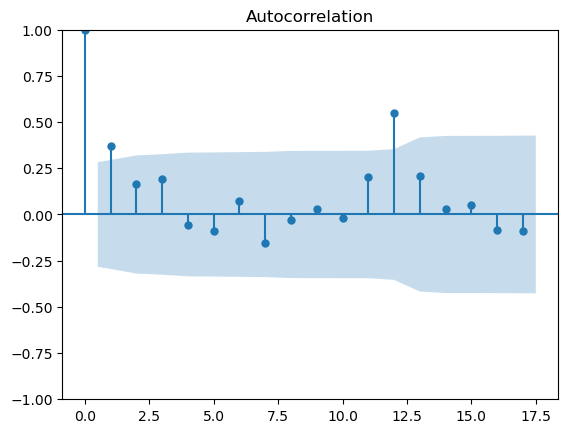

In [184]:
acf_plot = plot_acf(df2)

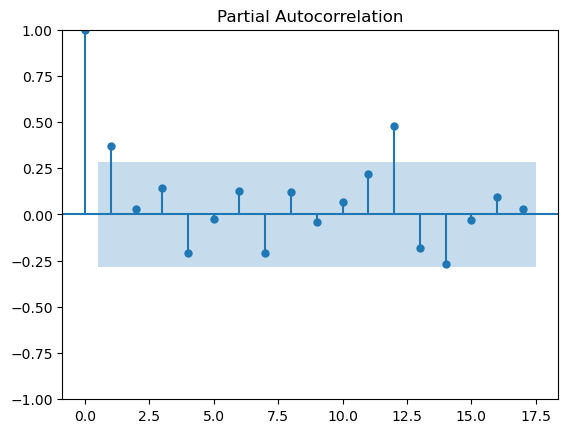

In [185]:
pacf_plot = plot_pacf(df2)

##### From the ACF and PACF plot, we can see that there is a correlation at lag = 1 and lag = 12

# Check for stationarity using the Augmented Dickey-Fuller (ADF) test

In [284]:
result = adfuller(df2)

adf_statistic = round(result[0],4)
p_value = round(result[1],4)
is_stationary = p_value < 0.05

print(f'ADF Statistic: {adf_statistic}')
print(f'p-value: {p_value}')
print(f'Is the time series stationary? {"Yes" if is_stationary else "No"}')

ADF Statistic: -4.425
p-value: 0.0003
Is the time series stationary? Yes


**Performing the Dickey-Fuller test for stationarity**

- H0: The time series is non-stationary.
- H1: The time series is stationary.
 
- Test statistics = -4.425
- P-Value = 0.0003

**Conclusion**

Since the p-value is not less than .05, we fail to reject the null hypothesis.
This means the time series is non-stationary. 
In other words, it has some time-dependent structure and does not have constant variance over time



# Fitting models

## Holt-Winters Exponential Smoothing model

The Holt-Winters Exponential Smoothing model is useful when dealing with time series data that exhibits trend and seasonality. The decision to use multiplicative or additive seasonality depends on the nature of the seasonal variations in the data.

1. When to Use Additive Seasonality?
   
Use an additive seasonality model when:
- Seasonal variations remain constant over time (e.g., the magnitude of seasonal peaks and troughs does not change significantly).
- The seasonal effect does not depend on the level of the series.
- The time series can be described as:

Example:

- Monthly temperature changes in a city where seasonal variations remain nearly the same year after year.
Retail sales with fixed seasonal increases/decreases.

2. When to Use Multiplicative Seasonality?
   
Use a multiplicative seasonality model when:
- Seasonal variations increase or decrease proportionally with the level of the series.
- The seasonal effect is dependent on the overall magnitude of the series.

Example:
- Sales of a product where high overall sales lead to larger seasonal fluctuations.
Airline passenger traffic, where seasonal peaks become larger over time as overall travel demand increases.

**Conclusion:**

- Since the Seasonal variations remain constant over time, i will fit a Holt-Winters Exponential Smoothing model with Additive seasonality

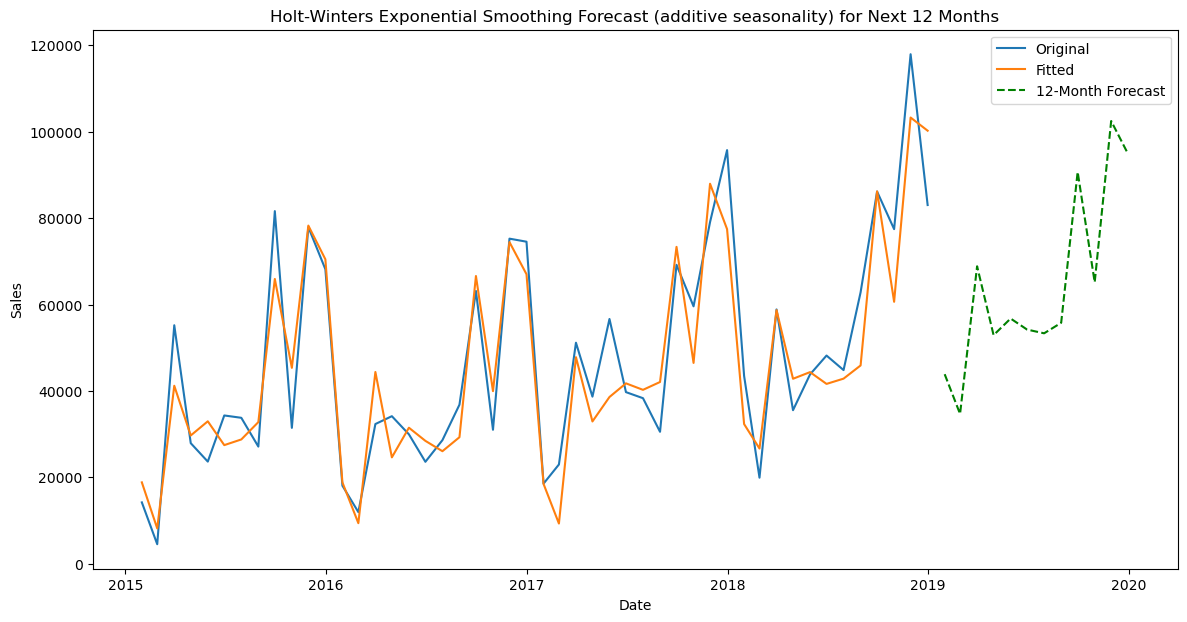

In [39]:

# Fit the Holt-Winters model with additive seasonality
fit_add = ExponentialSmoothing(df2, seasonal='additive', seasonal_periods=12).fit()
hw_additive_fitted = fit_add.fittedvalues

# Forecast sales for the next 12 months
forecast_12_months_add = fit_add.forecast(steps=12)

# Plot the original data and the forecast
plt.figure(figsize=(14, 7))
plt.plot(df2, label='Original')
plt.plot(hw_additive_fitted, label='Fitted')
plt.plot(forecast_12_months_add, label='12-Month Forecast', color='green', linestyle='--')
plt.title('Holt-Winters Exponential Smoothing Forecast (additive seasonality) for Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

## Autoregressive (AR)

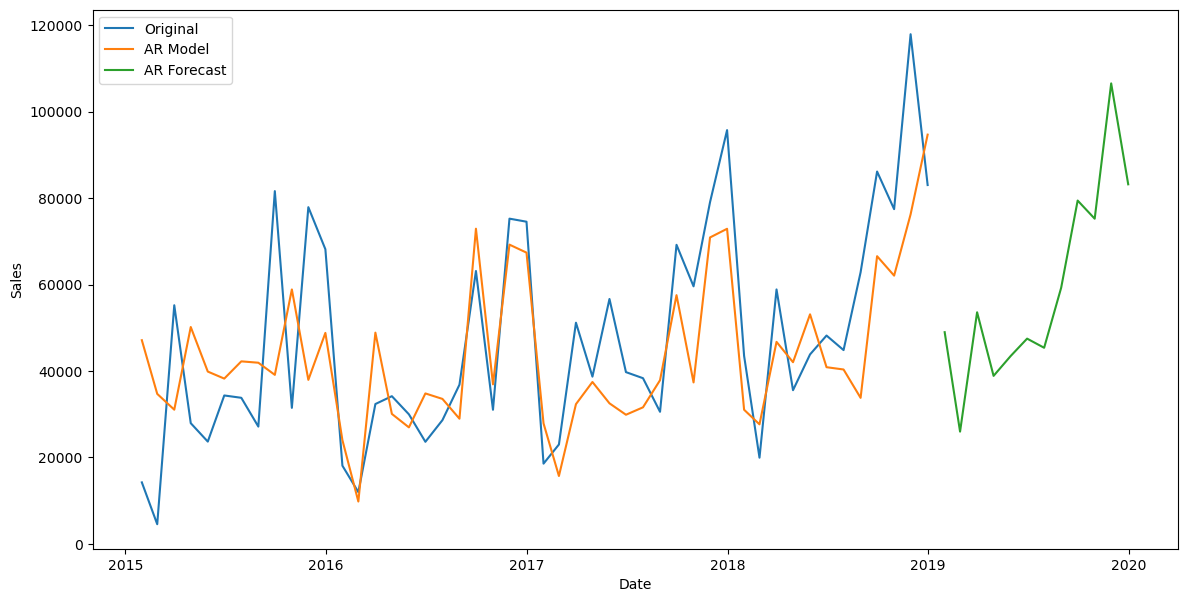

In [38]:
ar_model = ARIMA(df2, order=([1,12], 0, 0)).fit()
ar_fitted = ar_model.fittedvalues

ar_forecast_12_months = ar_model.forecast(steps=12)

plt.figure(figsize=(14, 7))
plt.plot(df2, label='Original')
plt.plot(ar_fitted, label='AR Model')
plt.plot(ar_forecast_12_months, label='AR Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()


## Moving Average (MA)

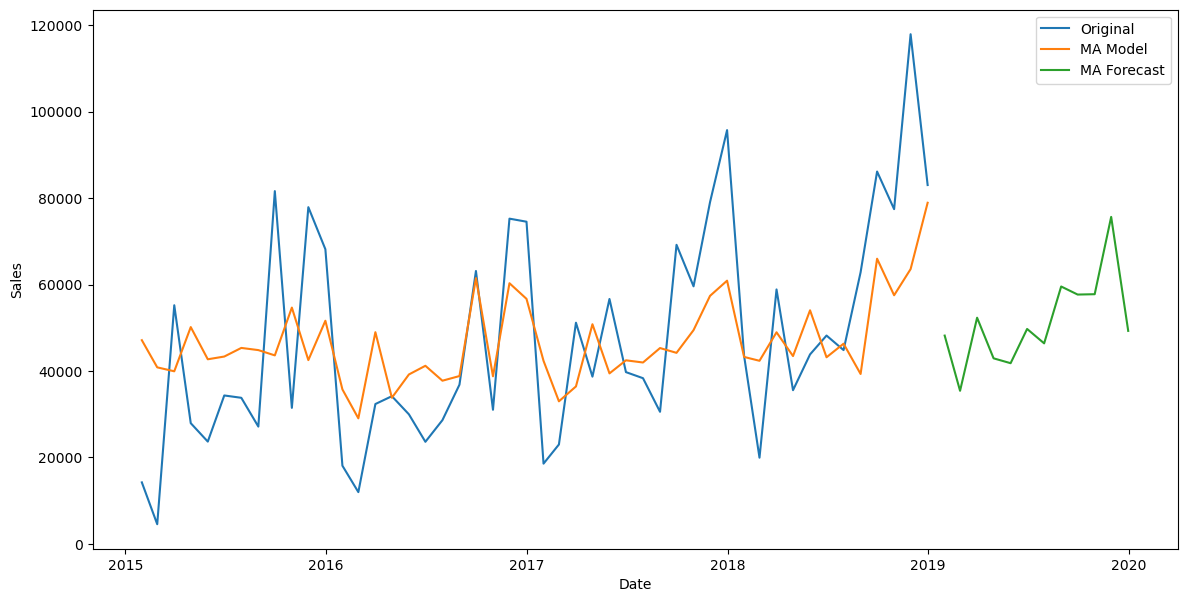

In [37]:
ma_model = ARIMA(df2, order=(0, 0, [1,12])).fit()
ma_fitted = ma_model.fittedvalues

ma_forecast_12_months = ma_model.forecast(steps=12)

plt.figure(figsize=(14, 7))
plt.plot(df2, label='Original')
plt.plot(ma_fitted, label='MA Model')
plt.plot(ma_forecast_12_months, label='MA Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()


## Autoregressive Integrated Moving Average (ARIMA)

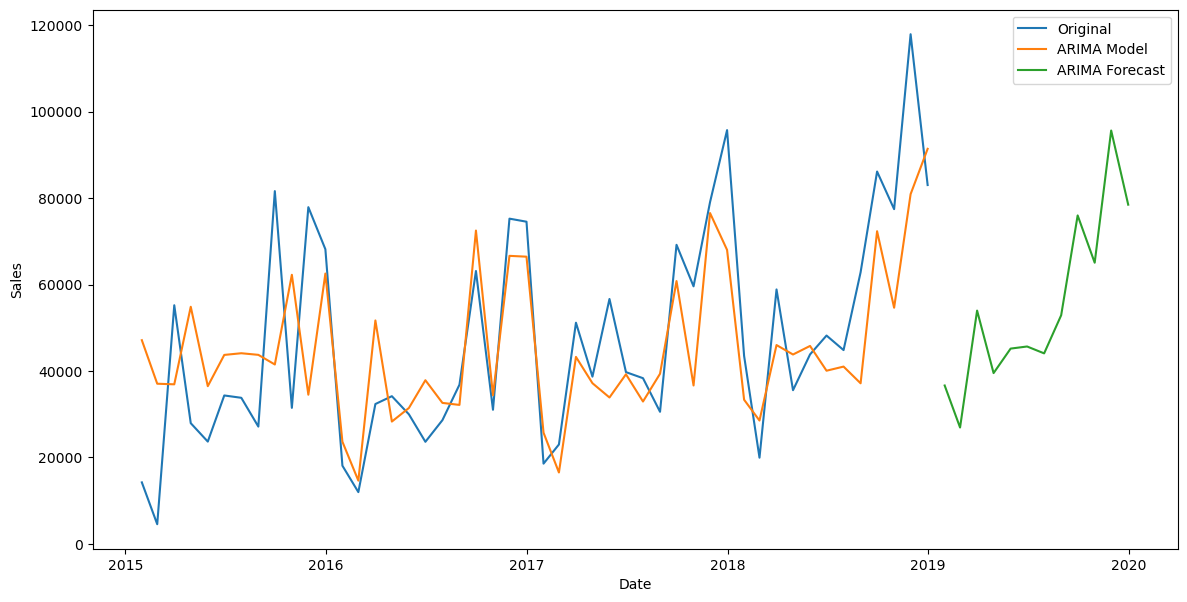

In [36]:
arima_model = ARIMA(df2, order=([1,12], 0, [1,12])).fit()
arima_fitted = arima_model.fittedvalues
arima_model_forecast_12_months = arima_model.forecast(steps=12)
plt.figure(figsize=(14, 7))
plt.plot(df2, label='Original')
plt.plot(arima_fitted, label='ARIMA Model')
plt.plot(arima_model_forecast_12_months, label='ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

## Seasonal Autoregressive Integrated Moving Average (SARIMA)

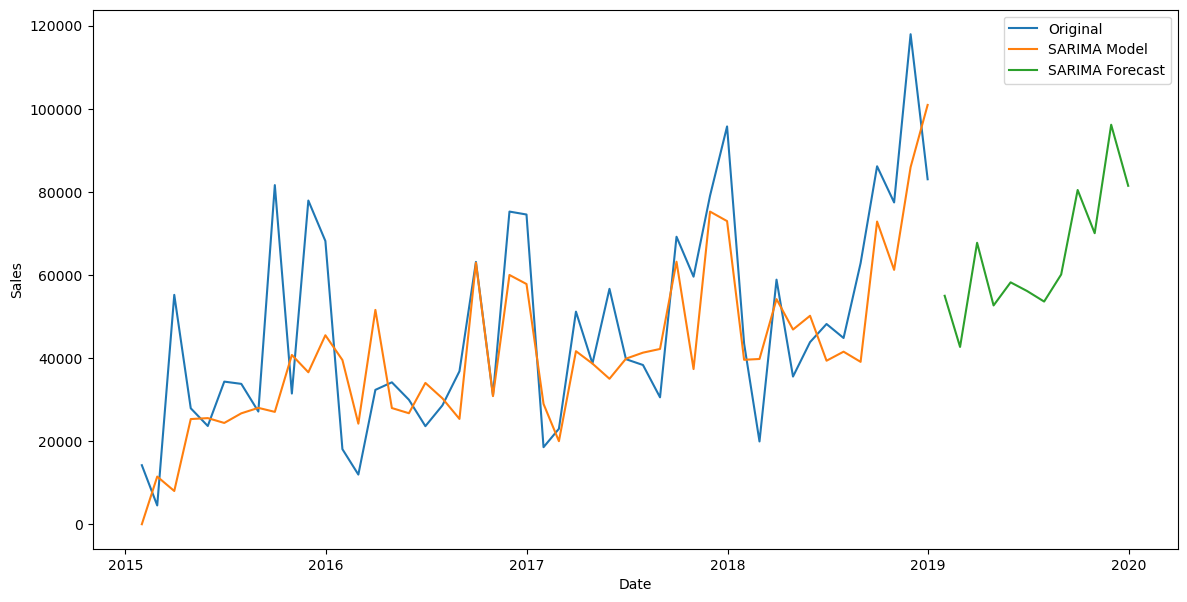

In [35]:
sarima_model = SARIMAX(df2, order=([1], 0, [1]), seasonal_order = ([1], 0, [1], 12)).fit()
sarima_fitted = sarima_model.fittedvalues

sarima_model_forecast_12_months = sarima_model.forecast(steps=12)

plt.figure(figsize=(14, 7))
plt.plot(df2, label='Original')
plt.plot(sarima_fitted, label='SARIMA Model')
plt.plot(sarima_model_forecast_12_months, label='SARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

## Model Performance

In [33]:
# Function to print model performance
def print_performance(model_name, actual, fitted_values):
    mse = round(mean_squared_error(actual, fitted_values),2)
    rmse = round(root_mean_squared_error(actual, fitted_values),2)
    mae = round(mean_absolute_error(actual, fitted_values),2)
    print(f'----------------------------------------------\n {model_name} \n')
    print(f'{model_name} - Mean Squared Error (MSE): {mse}')
    print(f'{model_name} - Root Mean Squared Error (RMSE): {rmse}')
    print(f'{model_name} - Mean Absolute Error (MAE): {mae}')


# Assessing the following models

print_performance('Holt-Winters Exponential Smoothing model (Additive Seasonality)', df2, hw_additive_fitted)

print_performance('AR', df2, ar_fitted)

print_performance('MA', df2, ma_fitted)

print_performance('ARIMA', df2, arima_fitted)

print_performance('SARIMA', df2, sarima_fitted)


----------------------------------------------
 Holt-Winters Exponential Smoothing model (Additive Seasonality) 

Holt-Winters Exponential Smoothing model (Additive Seasonality) - Mean Squared Error (MSE): 83389803.06
Holt-Winters Exponential Smoothing model (Additive Seasonality) - Root Mean Squared Error (RMSE): 9131.8
Holt-Winters Exponential Smoothing model (Additive Seasonality) - Mean Absolute Error (MAE): 7211.54
----------------------------------------------
 AR 

AR - Mean Squared Error (MSE): 319595396.65
AR - Root Mean Squared Error (RMSE): 17877.23
AR - Mean Absolute Error (MAE): 14451.01
----------------------------------------------
 MA 

MA - Mean Squared Error (MSE): 387595628.06
MA - Root Mean Squared Error (RMSE): 19687.45
MA - Mean Absolute Error (MAE): 16231.75
----------------------------------------------
 ARIMA 

ARIMA - Mean Squared Error (MSE): 306360185.14
ARIMA - Root Mean Squared Error (RMSE): 17503.15
ARIMA - Mean Absolute Error (MAE): 13556.22
------------

## Conclusion:
Based on these performance metrics, SARIMA appears to be the best performing model among the ones tested for your dataset. It demonstrates lower errors across all metrics (MSE, RMSE, MAE), suggesting that it captures the underlying patterns and seasonality in your data more effectively than AR, MA, and ARIMA models.
